# Fashion-MNIST brightness and contrast jitter (same batch, resampled)

Uses `make_fashion_mnist_dataloaders` from `inhibition/data.py`. Each row re-fetches the **same batch indices** through the dataset transform, so images stay fixed but `RandomAdjustBrightness` / `RandomAdjustContrast` draw anew. Contrast scales around each image's spatial mean, then brightness is applied. Under each thumbnail: μ / σ².

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from inhibition.data import make_fashion_mnist_dataloaders

In [12]:
DATA_DIR = "./data"
BRIGHTNESS_FACTOR = 0.75
BATCH_SIZE = 8
N_DRAWS = 4  # rows: same batch, new brightness each row

torch.manual_seed(23)

FMNIST_MEAN = 0.2860
FMNIST_STD = 0.3530

train_loader, _ = make_fashion_mnist_dataloaders(
    DATA_DIR,
    batch_size=BATCH_SIZE,
    test_batch_size=BATCH_SIZE,
    use_accel=True,
    brightness_factor=BRIGHTNESS_FACTOR,
    contrast_factor=0.0,
)

dataset = train_loader.dataset
batch_indices = list(range(BATCH_SIZE))  # first batch when use_accel=False (no shuffle)
targets = [dataset[i][1] for i in batch_indices]


def to_display(img: torch.Tensor) -> torch.Tensor:
    return (img * FMNIST_STD + FMNIST_MEAN).clamp(0.0, 1.0)


def show_image_with_moments(ax, img: torch.Tensor) -> None:
    vis = to_display(img).squeeze(0).cpu().numpy()
    mu = float(vis.mean())
    var = float(vis.var())
    ax.imshow(vis, cmap="gray", vmin=0, vmax=1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel(f"μ={mu:.2f}  σ²={var:.3f}", fontsize=8, color="0.15")


def plot_jitter_grid(ds, title: str):
    fig, axes = plt.subplots(
        N_DRAWS,
        BATCH_SIZE,
        figsize=(2.15 * BATCH_SIZE, 2.15 * N_DRAWS),
        gridspec_kw={"hspace": 0.45, "wspace": 0.2},
    )
    if N_DRAWS == 1:
        axes = axes.reshape(1, -1)
    names = ds.classes
    for row in range(N_DRAWS):
        for col, idx in enumerate(batch_indices):
            img, _ = ds[idx]
            show_image_with_moments(axes[row, col], img)
            if row == 0:
                axes[row, col].set_title(names[targets[col]], fontsize=9)
        axes[row, 0].set_ylabel(f"draw {row + 1}", fontsize=10)
    fig.suptitle(title, fontsize=12, y=0.98)
    plt.show()

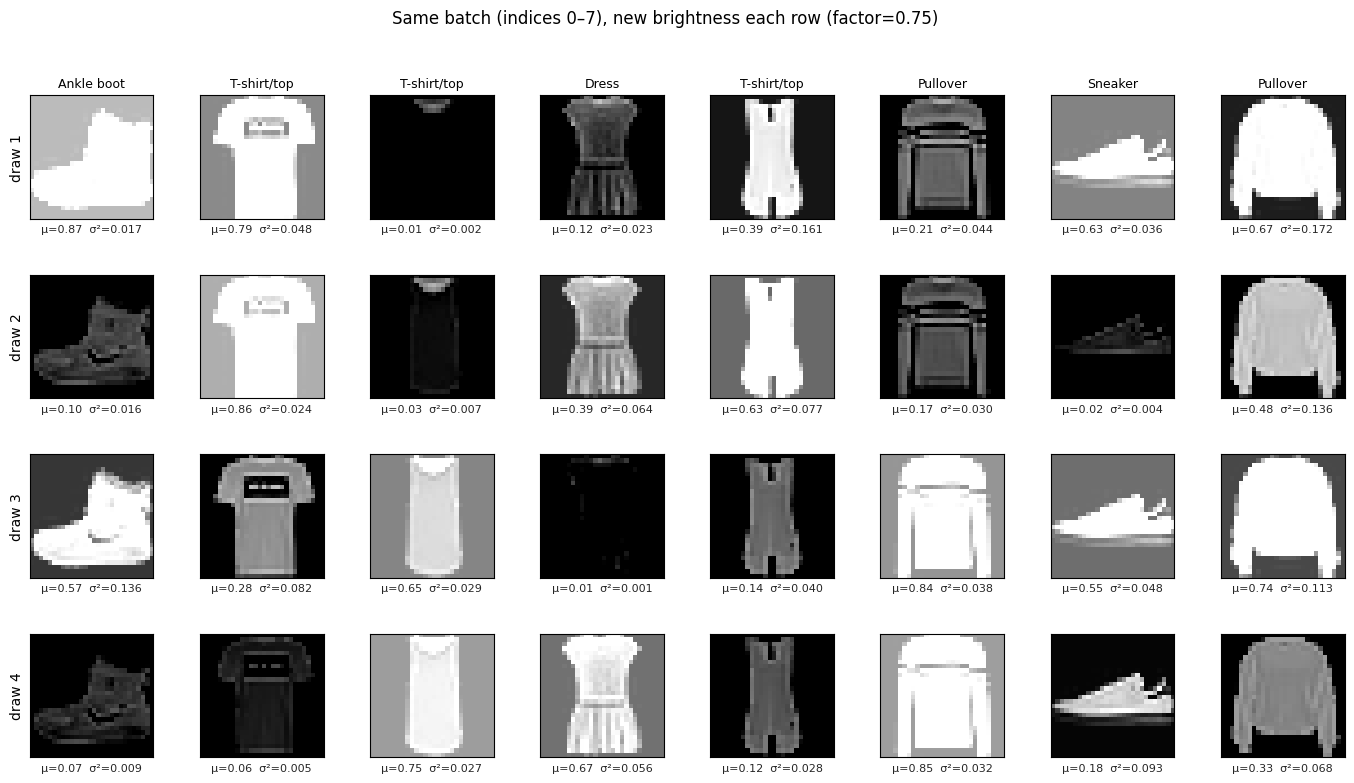

In [13]:
plot_jitter_grid(
    dataset,
    f"Same batch (indices 0–{BATCH_SIZE - 1}), new brightness each row "
    f"(factor={BRIGHTNESS_FACTOR})",
)

In [14]:
# Contrast jitter: same indices, brightness off
CONTRAST_FACTOR = 0.75

contrast_loader, _ = make_fashion_mnist_dataloaders(
    DATA_DIR,
    batch_size=BATCH_SIZE,
    test_batch_size=BATCH_SIZE,
    use_accel=True,
    brightness_factor=0.0,
    contrast_factor=CONTRAST_FACTOR,
)
contrast_dataset = contrast_loader.dataset

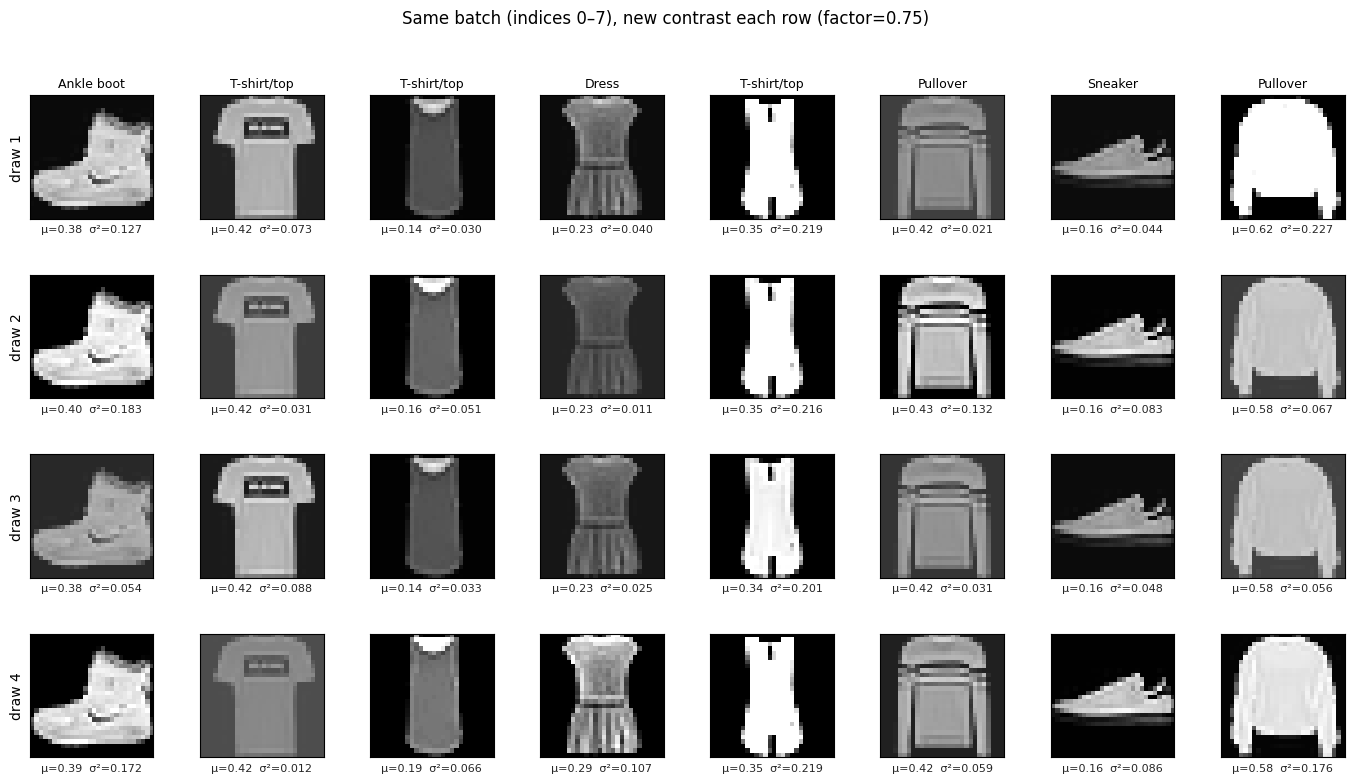

In [15]:
plot_jitter_grid(
    contrast_dataset,
    f"Same batch (indices 0–{BATCH_SIZE - 1}), new contrast each row "
    f"(factor={CONTRAST_FACTOR})",
)

## Fixed contrast multiplier `c`

No randomization: `x' = clamp((x − μ)c + μ, 0, 1)` on raw `[0, 1]` pixels (same formula as `RandomAdjustContrast`). `c = 1` is identity, `c = 0` is a flat mean image, `c > 1` stretches, **`c < 0` inverts around the mean** (a photographic negative of the deviations). Random `γ > 1` can sample those negative `c` values.

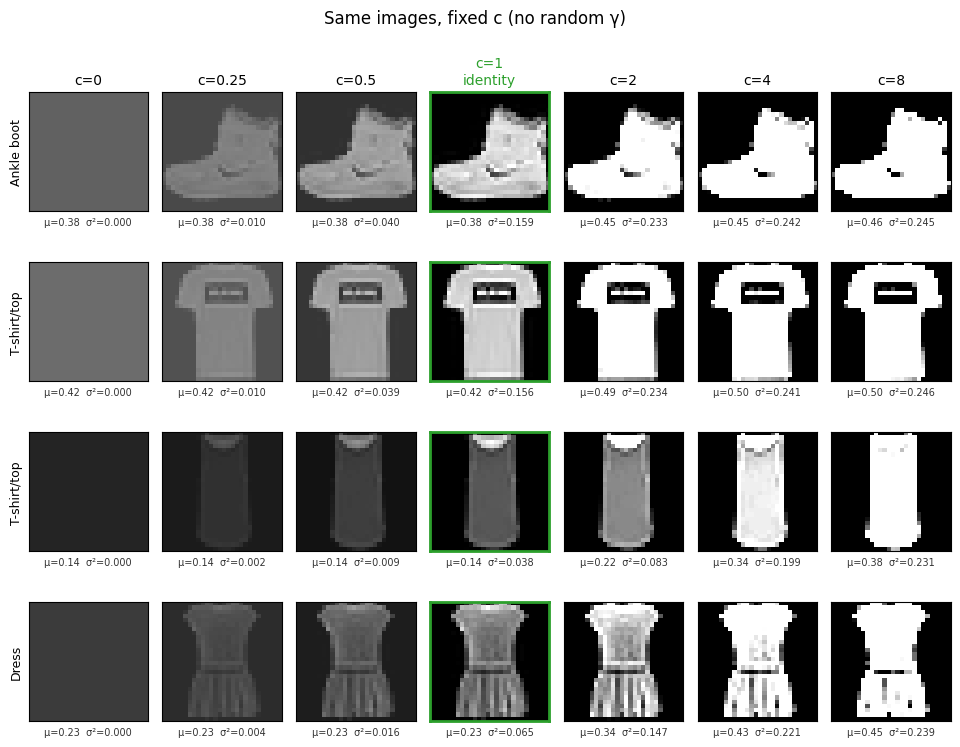

In [6]:
from torchvision import datasets, transforms

C_VALUES = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
N_C_IMAGES = 4

raw_set = datasets.FashionMNIST(
    DATA_DIR, train=True, download=True, transform=transforms.ToTensor()
)


def apply_contrast_c(x: torch.Tensor, c: float) -> torch.Tensor:
    mu_img = x.mean(dim=(-2, -1), keepdim=True)
    return ((x - mu_img) * c + mu_img).clamp(0.0, 1.0)


fig, axes = plt.subplots(
    N_C_IMAGES,
    len(C_VALUES),
    figsize=(1.7 * len(C_VALUES), 2.05 * N_C_IMAGES),
    gridspec_kw={"hspace": 0.4, "wspace": 0.12},
)
class_names = raw_set.classes
for row, idx in enumerate(batch_indices[:N_C_IMAGES]):
    x0, y = raw_set[idx]
    for col, c in enumerate(C_VALUES):
        vis = apply_contrast_c(x0, c).squeeze(0).numpy()
        ax = axes[row, col]
        ax.imshow(vis, cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(f"μ={vis.mean():.2f}  σ²={vis.var():.3f}", fontsize=7, color="0.2")
        if c == 1.0:
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_color("C2")
                spine.set_linewidth(2)
        if row == 0:
            title = f"c={c:g}" + ("\nidentity" if c == 1.0 else "")
            ax.set_title(title, fontsize=10, color="C2" if c == 1.0 else "black")
    axes[row, 0].set_ylabel(class_names[y], fontsize=9)

fig.suptitle("Same images, fixed c (no random γ)", fontsize=12)
plt.show()

## Fixed brightness offset `δ`

Additive, no randomization: `x' = clamp(x + δ, 0, 1)` (same as `RandomAdjustBrightness`). **`δ = 0` is identity.** Negative `δ` darkens; positive `δ` brightens.

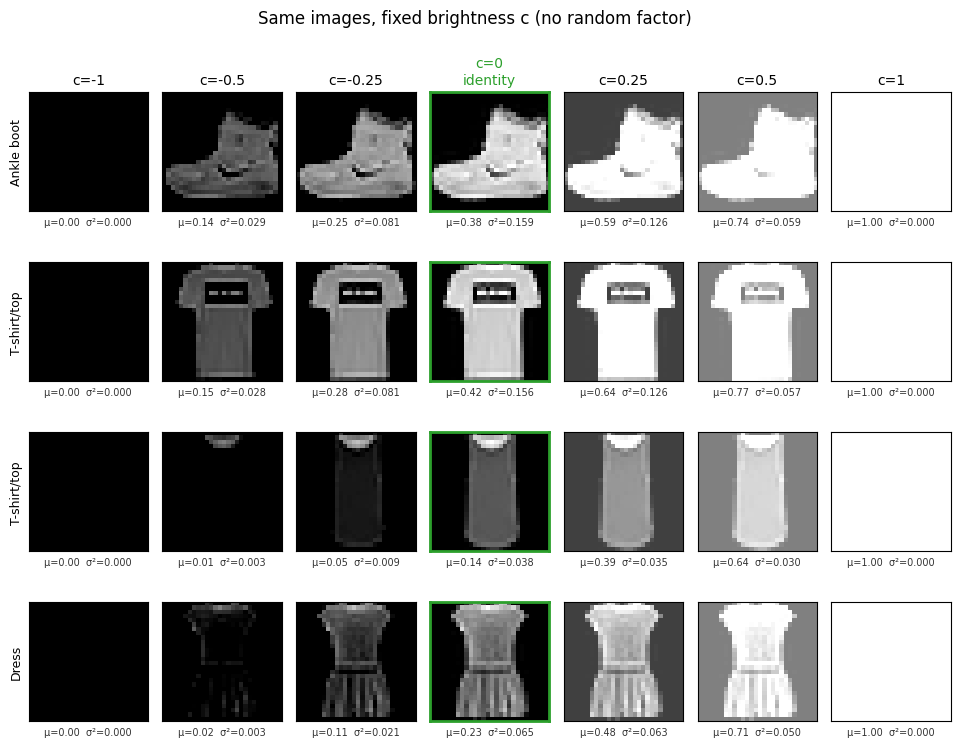

In [8]:
DELTA_VALUES = [-1.0, -0.5, -0.25, 0.0, 0.25, 0.5, 1.0]


def apply_brightness_delta(x: torch.Tensor, delta: float) -> torch.Tensor:
    return (x + delta).clamp(0.0, 1.0)


fig, axes = plt.subplots(
    N_C_IMAGES,
    len(DELTA_VALUES),
    figsize=(1.7 * len(DELTA_VALUES), 2.05 * N_C_IMAGES),
    gridspec_kw={"hspace": 0.4, "wspace": 0.12},
)
class_names = raw_set.classes
for row, idx in enumerate(batch_indices[:N_C_IMAGES]):
    x0, y = raw_set[idx]
    for col, delta in enumerate(DELTA_VALUES):
        vis = apply_brightness_delta(x0, delta).squeeze(0).numpy()
        ax = axes[row, col]
        ax.imshow(vis, cmap="gray", vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(f"μ={vis.mean():.2f}  σ²={vis.var():.3f}", fontsize=7, color="0.2")
        if delta == 0.0:
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_color("C2")
                spine.set_linewidth(2)
        if row == 0:
            title = f"c={delta:g}" + ("\nidentity" if delta == 0.0 else "")
            ax.set_title(title, fontsize=10, color="C2" if delta == 0.0 else "black")
    axes[row, 0].set_ylabel(class_names[y], fontsize=9)

fig.suptitle("Same images, fixed brightness c (no random factor)", fontsize=12)
plt.show()

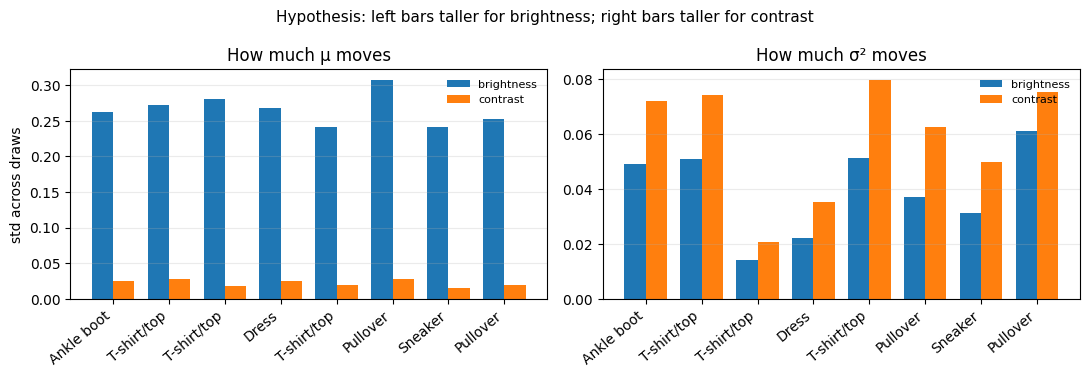

In [16]:
N_MOMENT_DRAWS = 64


def collect_moments(ds, indices, k: int):
    mus = np.zeros((len(indices), k))
    vars_ = np.zeros((len(indices), k))
    for j, idx in enumerate(indices):
        for t in range(k):
            x = to_display(ds[idx][0])
            mus[j, t] = x.mean().item()
            vars_[j, t] = x.var(unbiased=False).item()
    return mus, vars_


mu_b, var_b = collect_moments(dataset, batch_indices, N_MOMENT_DRAWS)
mu_c, var_c = collect_moments(contrast_dataset, batch_indices, N_MOMENT_DRAWS)

std_mu_b, std_var_b = mu_b.std(axis=1), var_b.std(axis=1)
std_mu_c, std_var_c = mu_c.std(axis=1), var_c.std(axis=1)
names = dataset.classes
x = np.arange(BATCH_SIZE)
w = 0.38

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharex=True)
axes[0].bar(x - w / 2, std_mu_b, w, color="C0", label="brightness")
axes[0].bar(x + w / 2, std_mu_c, w, color="C1", label="contrast")
axes[0].set_ylabel("std across draws")
axes[0].set_title("How much μ moves")
axes[1].bar(x - w / 2, std_var_b, w, color="C0", label="brightness")
axes[1].bar(x + w / 2, std_var_c, w, color="C1", label="contrast")
axes[1].set_title("How much σ² moves")
for ax in axes:
    ax.set_xticks(x)
    ax.set_xticklabels([names[targets[j]] for j in range(BATCH_SIZE)], rotation=40, ha="right")
    ax.legend(frameon=False, fontsize=8)
    ax.grid(True, axis="y", alpha=0.25)
fig.suptitle("Hypothesis: left bars taller for brightness; right bars taller for contrast", fontsize=11)
plt.tight_layout()
plt.show()